✓ Packages installed and imported
✓ Physics constants loaded
✓ Physics functions defined
✓ GP training function defined
📥 Downloading data from GitHub...
✓ Loaded 31 valid beams
  Str/w range: [7.12, 33.60] N/g

✓ Data prepared
  Total beams: 31
  FINAL best beam: b=3.63mm, r=1.50mm, ΔH=-4.15mm → Str/w=33.60 N/g
  Slice location fixed at this beam
✓ Frame generation function defined

GENERATING ANIMATION
Configuration:
  Initial beams: 1
  Step size: 1
  Plot every: 1
  Total frames: 31
  Animation FPS: 3
  Noise level: 3e-03

Slice location: b=3.63mm, r=1.50mm, ΔH=-4.15mm → Str/w=33.60 N/g

Generating frames...

✓ Generated 31 frames

Saving animation: gp_learning_b_vs_strw.gif
✓ Animation saved!
  File: gp_learning_b_vs_strw.gif
  Frames: 31
  Duration: 10.3 seconds
  Size: 31 frames

DISPLAYING ANIMATION


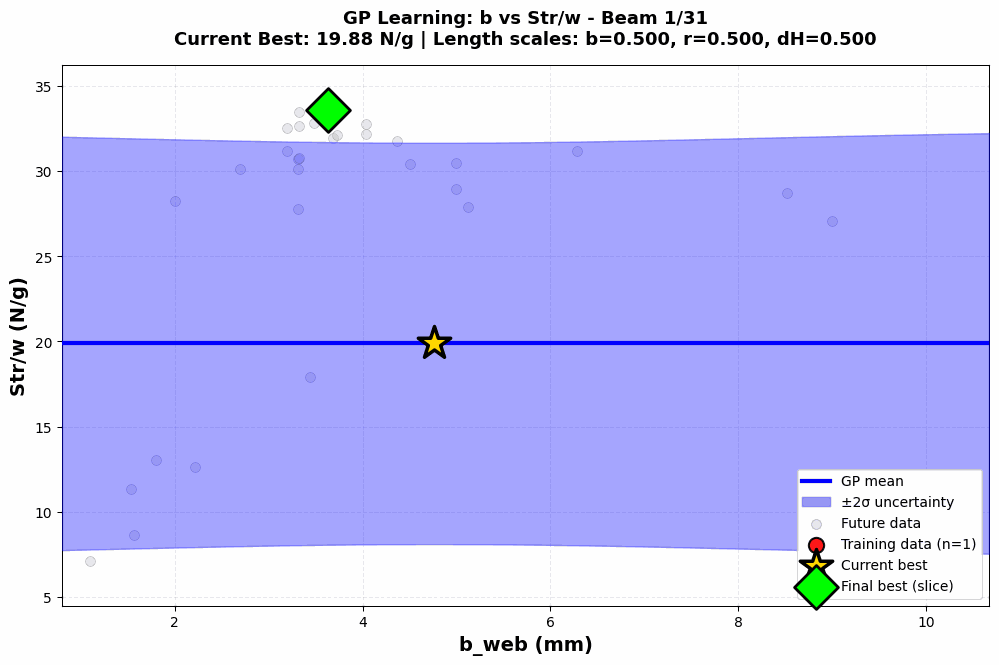


✓ Animation displayed above!

💡 TIP: Right-click the animation to save it to your computer

SUMMARY

Animation Details:
  File: gp_learning_b_vs_strw.gif
  Frames: 31
  Duration: 10.3 seconds
  FPS: 3
  
Data:
  Total beams: 31
  Initial: 1
  Step size: 1
  
Final Best Beam (slice location):
  b = 3.63 mm
  r = 1.50 mm
  ΔH = -4.15 mm
  Str/w = 33.60 N/g
  
GP Settings:
  Noise: 3e-03
  Length scales: free
  
Key Observations:
  - Uncertainty (blue band) shrinks as data accumulates
  - Mean prediction improves to match training data
  - Final best beam (green diamond) is the slice location
  - Current best beam (gold star) may change over time
  
To modify:
  - Adjust CONFIGURATION section at top
  - Rerun all cells

✓ COMPLETE!


In [1]:
"""
GOOGLE COLAB: GP Learning Animation - 1D b vs Str/w
====================================================
Watch how the Gaussian Process learns the effect of web thickness (b)
on strength-to-weight ratio as beams are tested one by one.

Sliced at the location of the final strongest beam.

INSTRUCTIONS:
1. Run all cells (Runtime > Run all)
2. Animation will be saved and displayed at the end
3. Adjust parameters in CONFIGURATION section below
"""

# ==========================================
# CONFIGURATION - ADJUST THESE!
# ==========================================

# Data settings
INITIAL_DATA_SIZE = 1     # Start with first 15 beams (LHS)
STEP_SIZE = 1              # Add 1 beam at a time
PLOT_EVERY = 1             # Plot after every addition (use 2-3 for faster)

# GP settings
NOISE_LEVEL = 3e-3         # Observation noise (1e-3=low, 3e-3=realistic, 1e-2=high)
LENGTH_SCALE_MODE = 'free' # 'free' (learn per param), 'fixed' (manual)

# Animation settings
ANIMATION_FPS = 3          # Frames per second (1=slow, 5=fast)
ANIMATION_FILENAME = 'gp_learning_b_vs_strw.gif'

# Plot styling
FIGURE_SIZE = (10, 6)      # (width, height) in inches
DPI = 100                  # Resolution (100=screen, 150=high quality)

# ==========================================
# INSTALLATION & IMPORTS
# ==========================================

# Install required packages
!pip install -q scikit-learn matplotlib pandas numpy Pillow imageio

import pandas as pd
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, Image
import warnings
warnings.filterwarnings("ignore")

print("✓ Packages installed and imported")

# ==========================================
# PHYSICS CONSTANTS
# ==========================================

TOTAL_HEIGHT = 25.0
B_FIXED = 16.0
MIN_WEB_THICKNESS = 0.8
MIN_FLANGE_WIDTH = 8.0
MAX_WEB_RATIO = 2/3
MATERIAL_DENSITY = 1240
LENGTH_M = 0.2023
YIELD_STRENGTH = 76000000
BOUNDS_3D = {'b': (0.8, 10.67), 'r': (0.0, 4.0), 'delta_H': (-6.0, 4.0)}

print("✓ Physics constants loaded")

# ==========================================
# PHYSICS CALCULATIONS
# ==========================================

def calc_I(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    I_web = (H_m**3 * b_m) / 12
    I_fl = (h_m**3 * B_m) / 12 + h_m * B_m * ((H_m + h_m) / 2)**2
    return I_web + 2*I_fl

def calc_mass(H, h, B, b):
    H_m, h_m, B_m, b_m = H/1000, h/1000, B/1000, b/1000
    return MATERIAL_DENSITY * LENGTH_M * (H_m*b_m + 2*h_m*B_m) * 1000

def calc_strength(H, h, B, b):
    return (4 * YIELD_STRENGTH * calc_I(H, h, B, b)) / (0.0125 * LENGTH_M)

def calc_str_w(H, B, b):
    h = (TOTAL_HEIGHT - H) / 2.0
    return calc_strength(H, h, B, b) / calc_mass(H, h, B, b)

def find_H_opt(b, B=B_FIXED):
    from scipy.optimize import minimize_scalar
    def obj(H):
        if H < 12.0 or H > 23.4: return 1e10
        h = (TOTAL_HEIGHT - H) / 2.0
        if h < 0 or h > 6.5: return 1e10
        return -calc_str_w(H, B, b)
    return minimize_scalar(obj, bounds=(12.0, 23.4), method='bounded').x

def check_3d(b, r, delta_H):
    H_phys = find_H_opt(b)
    H = H_phys + delta_H
    h = (TOTAL_HEIGHT - H) / 2.0
    if not (12.0 <= H <= 23.4 and 0 <= h <= 6.5): return False
    if not (MIN_WEB_THICKNESS <= b <= MAX_WEB_RATIO*B_FIXED): return False
    return 0 <= r <= (B_FIXED - b)/2.0

def transform_4d_to_3d(X_4d):
    X_3d = []
    for i in range(len(X_4d)):
        b, r = X_4d[i, 2], X_4d[i, 3]
        H_phys = find_H_opt(b)
        delta_H = X_4d[i, 0] - H_phys
        X_3d.append([b, r, delta_H])
    return np.array(X_3d)

def normalize(X):
    X_n = np.copy(X).astype(float)
    for i, k in enumerate(['b', 'r', 'delta_H']):
        X_n[:, i] = (X[:, i] - BOUNDS_3D[k][0]) / (BOUNDS_3D[k][1] - BOUNDS_3D[k][0])
    return X_n

def denormalize(X_n):
    X = np.copy(X_n)
    for i, k in enumerate(['b', 'r', 'delta_H']):
        X[:, i] = X_n[:, i] * (BOUNDS_3D[k][1] - BOUNDS_3D[k][0]) + BOUNDS_3D[k][0]
    return X

print("✓ Physics functions defined")

# ==========================================
# GP TRAINING
# ==========================================

def train_gp(X_3d, y):
    """Train Gaussian Process on current data"""
    X_norm = normalize(X_3d)
    y_log = np.log(y)
    y_mean, y_cent = np.mean(y_log), y_log - np.mean(y_log)

    if LENGTH_SCALE_MODE == 'fixed':
        kernel = ConstantKernel(1.0, (0.1, 10.0)) * Matern(
            length_scale=[0.5, 0.5, 0.5], length_scale_bounds='fixed', nu=2.5)
    else:
        kernel = ConstantKernel(1.0, (0.1, 10.0)) * Matern(
            length_scale=[0.5]*3, length_scale_bounds=(0.1, 3.0), nu=2.5)

    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25,
                                   alpha=NOISE_LEVEL, normalize_y=False)
    gp.fit(X_norm, y_cent)

    return gp, X_norm, y_cent, y_mean

print("✓ GP training function defined")

# ==========================================
# DATA LOADING
# ==========================================

def load_data():
    """Load I-beam data from GitHub"""
    import urllib.request
    import io

    DATA_URL = "https://raw.githubusercontent.com/andrewvoss8-boop/core-me-data-science-activities-public/main/data/I_beam_data.csv"

    print(f"📥 Downloading data from GitHub...")
    with urllib.request.urlopen(DATA_URL) as response:
        csv_data = response.read().decode('utf-8')

    df = pd.read_csv(io.StringIO(csv_data))

    param_names_4d = ['H_web_height', 'B_flange_width', 'b_web_thick', 'r_fillet']
    required_cols = param_names_4d + ['Str/w (N/g)']
    df_clean = df[required_cols].dropna()

    def meets_constraints(row):
        H = row['H_web_height']
        B = row['B_flange_width']
        b = row['b_web_thick']
        r = row['r_fillet']
        h = (TOTAL_HEIGHT - H) / 2.0
        if B < MIN_FLANGE_WIDTH or b < MIN_WEB_THICKNESS or b > MAX_WEB_RATIO * B:
            return False
        if r < 0 or r > (B - b) / 2.0:
            return False
        if h < 0 or h > 6.5:
            return False
        return True

    df_constrained = df_clean[df_clean.apply(meets_constraints, axis=1)].copy()

    print(f"✓ Loaded {len(df_constrained)} valid beams")
    print(f"  Str/w range: [{df_constrained['Str/w (N/g)'].min():.2f}, "
          f"{df_constrained['Str/w (N/g)'].max():.2f}] N/g")

    return df_constrained

# Load data
df = load_data()
X_4d_all = df[['H_web_height', 'B_flange_width', 'b_web_thick', 'r_fillet']].values
y_all = df['Str/w (N/g)'].values
X_3d_all = transform_4d_to_3d(X_4d_all)
X_norm_all = normalize(X_3d_all)

# Find FINAL best beam (for slice location)
final_best_idx = np.argmax(y_all)
final_best_beam = X_3d_all[final_best_idx]
final_best_str_w = y_all[final_best_idx]
slice_point_norm = normalize(final_best_beam.reshape(1, -1))[0]

print(f"\n✓ Data prepared")
print(f"  Total beams: {len(y_all)}")
print(f"  FINAL best beam: b={final_best_beam[0]:.2f}mm, r={final_best_beam[1]:.2f}mm, "
      f"ΔH={final_best_beam[2]:.2f}mm → Str/w={final_best_str_w:.2f} N/g")
print(f"  Slice location fixed at this beam")

# ==========================================
# FRAME GENERATION
# ==========================================

def create_frame(ax, n_beams, X_3d_all, y_all, X_norm_all, slice_point_norm):
    """Create a single frame showing GP state at this iteration"""

    # Current data subset
    X_3d_current = X_3d_all[:n_beams]
    y_current = y_all[:n_beams]

    # Train GP
    gp, X_norm_current, y_cent, y_mean = train_gp(X_3d_current, y_current)

    # Get learned length scales
    if LENGTH_SCALE_MODE != 'fixed':
        scales = gp.kernel_.k2.length_scale
        scale_str = f"b={scales[0]:.3f}, r={scales[1]:.3f}, dH={scales[2]:.3f}"
    else:
        scale_str = "Fixed"

    # Current best
    current_best_idx = np.argmax(y_current)
    current_best_str_w = y_current[current_best_idx]

    # Clear axis
    ax.clear()

    # Generate prediction along b dimension (at slice point)
    X_test = np.tile(slice_point_norm, (100, 1))
    X_test[:, 0] = np.linspace(0, 1, 100)  # Vary b

    mu, sig = gp.predict(X_test, return_std=True)
    mu_r = np.exp(mu + y_mean)
    epistemic_std = np.exp(mu + y_mean) * sig

    b_vals = denormalize(X_test)[:, 0]

    # Plot GP prediction
    ax.plot(b_vals, mu_r, 'b-', lw=3, label='GP mean', zorder=5)
    ax.fill_between(b_vals, mu_r - 2*epistemic_std, mu_r + 2*epistemic_std,
                    alpha=0.35, color='blue', label='±2σ uncertainty', zorder=4)

    # Plot all data (future = gray)
    X_den_all = denormalize(X_norm_all)
    ax.scatter(X_den_all[:, 0], y_all, c='lightgray', s=50, alpha=0.5,
              ec='gray', lw=0.5, zorder=2, label='Future data')

    # Plot current training data (red)
    X_den_current = denormalize(X_norm_current)
    ax.scatter(X_den_current[:, 0], y_current, c='red', s=120, alpha=0.9,
              ec='black', lw=1.5, zorder=6, label=f'Training data (n={n_beams})')

    # Highlight current best
    ax.scatter([X_den_current[current_best_idx, 0]], [current_best_str_w],
              s=600, marker='*', c='gold', ec='black', lw=2.5, zorder=10,
              label=f'Current best')

    # Highlight final best (slice location)
    ax.scatter([final_best_beam[0]], [final_best_str_w],
              s=500, marker='D', c='lime', ec='black', lw=2, zorder=9,
              label=f'Final best (slice)')

    # Styling
    ax.set_xlabel('b_web (mm)', fontsize=14, weight='bold')
    ax.set_ylabel('Str/w (N/g)', fontsize=14, weight='bold')
    ax.set_title(f'GP Learning: b vs Str/w - Beam {n_beams}/{len(y_all)}\n'
                f'Current Best: {current_best_str_w:.2f} N/g | '
                f'Length scales: {scale_str}',
                fontsize=13, weight='bold', pad=15)
    ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_xlim(BOUNDS_3D['b'][0], BOUNDS_3D['b'][1])

    # Find y limits from data
    y_min, y_max = y_all.min(), y_all.max()
    y_range = y_max - y_min
    ax.set_ylim(y_min - 0.1*y_range, y_max + 0.1*y_range)

    return ax

print("✓ Frame generation function defined")

# ==========================================
# CREATE ANIMATION
# ==========================================

print("\n" + "="*70)
print("GENERATING ANIMATION")
print("="*70)

# Determine frames to generate
frame_indices = list(range(INITIAL_DATA_SIZE, len(y_all) + 1, STEP_SIZE))
if frame_indices[-1] != len(y_all):
    frame_indices.append(len(y_all))  # Ensure last frame included

frame_indices = [idx for i, idx in enumerate(frame_indices) if (i % PLOT_EVERY) == 0]

print(f"Configuration:")
print(f"  Initial beams: {INITIAL_DATA_SIZE}")
print(f"  Step size: {STEP_SIZE}")
print(f"  Plot every: {PLOT_EVERY}")
print(f"  Total frames: {len(frame_indices)}")
print(f"  Animation FPS: {ANIMATION_FPS}")
print(f"  Noise level: {NOISE_LEVEL:.0e}")
print(f"\nSlice location: b={final_best_beam[0]:.2f}mm, r={final_best_beam[1]:.2f}mm, "
      f"ΔH={final_best_beam[2]:.2f}mm → Str/w={final_best_str_w:.2f} N/g")
print(f"\nGenerating frames...")

# Create figure
fig, ax = plt.subplots(figsize=FIGURE_SIZE, dpi=DPI)
plt.tight_layout()

# Generate all frames
frames = []
for i, n_beams in enumerate(frame_indices):
    print(f"  Frame {i+1}/{len(frame_indices)}: {n_beams} beams "
          f"(best={y_all[:n_beams].max():.2f})", end='\r')

    create_frame(ax, n_beams, X_3d_all, y_all, X_norm_all, slice_point_norm)

    # Save frame to buffer
    import io
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=DPI, bbox_inches='tight')
    buf.seek(0)
    from PIL import Image
    frames.append(Image.open(buf).copy())
    buf.close()

plt.close(fig)
print(f"\n✓ Generated {len(frames)} frames")

# Save animation
print(f"\nSaving animation: {ANIMATION_FILENAME}")
import imageio
frame_arrays = [np.array(frame) for frame in frames]
imageio.mimsave(ANIMATION_FILENAME, frame_arrays, fps=ANIMATION_FPS, loop=0)

print(f"✓ Animation saved!")
print(f"  File: {ANIMATION_FILENAME}")
print(f"  Frames: {len(frames)}")
print(f"  Duration: {len(frames)/ANIMATION_FPS:.1f} seconds")
print(f"  Size: {len(frame_arrays)} frames")

# ==========================================
# DISPLAY ANIMATION
# ==========================================

print("\n" + "="*70)
print("DISPLAYING ANIMATION")
print("="*70)

# Display in Colab
from IPython.display import Image as IPImage
display(IPImage(ANIMATION_FILENAME))

print("\n✓ Animation displayed above!")
print("\n💡 TIP: Right-click the animation to save it to your computer")

# ==========================================
# SUMMARY
# ==========================================

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"""
Animation Details:
  File: {ANIMATION_FILENAME}
  Frames: {len(frames)}
  Duration: {len(frames)/ANIMATION_FPS:.1f} seconds
  FPS: {ANIMATION_FPS}

Data:
  Total beams: {len(y_all)}
  Initial: {INITIAL_DATA_SIZE}
  Step size: {STEP_SIZE}

Final Best Beam (slice location):
  b = {final_best_beam[0]:.2f} mm
  r = {final_best_beam[1]:.2f} mm
  ΔH = {final_best_beam[2]:.2f} mm
  Str/w = {final_best_str_w:.2f} N/g

GP Settings:
  Noise: {NOISE_LEVEL:.0e}
  Length scales: {LENGTH_SCALE_MODE}

Key Observations:
  - Uncertainty (blue band) shrinks as data accumulates
  - Mean prediction improves to match training data
  - Final best beam (green diamond) is the slice location
  - Current best beam (gold star) may change over time

To modify:
  - Adjust CONFIGURATION section at top
  - Rerun all cells
""")

print("="*70)
print("✓ COMPLETE!")
print("="*70)